In [10]:
from CRNs import *
import numpy as np
import argparse
import time
import copy
import pickle


n_species = 8
n_complexes = 9
n_reactions = 12
force_reverse = True
L = np.array([[2, 1, 1, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 2, 1, 1, 1]])
n_cons = len(L)
n_lcs = n_complexes - n_species + n_cons
complexes_per_class = [2, 3, 4]
reactions_per_class = [1, 3, 6]
subset_group_ind = None
seed = 30

E_range = 1
B_range = 1
F_range = 5
C0 = 1
beta = 1

n_graph_samples = 50
n_sign_samples = 50

t_span = (0, 10000)
num_points = 10000
int_method = 'Radau'
r_tol = 1e-4    
a_tol = 1e-4

if seed is not None:
    np.random.seed(seed)
    random.seed(seed)

sign_conditions_list = []
M_0t1_list = []
M_1t0_list = []
M_0b1_list = []
r_n_list = []
n_cycles_list = []

# Initialize time profiler
profiler = TimeProfiler()
profiler.start_total_timer()
for iter in range(n_graph_samples):
    seed = np.random.randint(1000000)

    # Time network generation
    profiler.start_timer("network_generation")
    try:
        r_n = ReactionNetwork(  
            n_species, 
            n_complexes, n_reactions, n_lcs, 
            L, seed, force_reverse=force_reverse, subset_group_ind=subset_group_ind, 
            complexes_per_class=complexes_per_class, reactions_per_class=reactions_per_class
    )
        reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
        r_n.update_rates(reac_rates)
        profiler.end_timer("network_generation")
    except Exception as e:
        profiler.end_timer("network_generation")
        print(f"Error creating reaction network: {e}, skipping...")
        continue

    # Time conservation group analysis
    profiler.start_timer("conservation_analysis")
    M_0t1, M_1t0, M_0b1 = count_conservation_group_changes(r_n)
    profiler.end_timer("conservation_analysis")
    
    # Time data storage operations
    profiler.start_timer("data_storage")
    M_0t1_list.append(M_0t1)
    M_1t0_list.append(M_1t0)
    M_0b1_list.append(M_0b1)
    cycles = compute_cycles(r_n)
    n_cycles_list.append(len(cycles))
    # Store the parameters used to create the network (can recreate later)
    r_n_params = {
        'all_complexes': r_n.all_complexes,
        'reactions': r_n.reactions
    }
    r_n_list.append(r_n_params)
    profiler.end_timer("data_storage")

    # Time simulator initialization
    profiler.start_timer("simulator_init")
    sim = ReactionNetworkSimulator(r_n)
    profiler.end_timer("simulator_init")
    
    # Time symbolic computations
    profiler.start_timer("symbolic_computations")
    
    # Time conservation laws solving
    profiler.start_timer("conservation_laws")
    sim.solve_conservation_laws()
    profiler.end_timer("conservation_laws")
    
    # Time symbolic RHS generation
    profiler.start_timer("symbolic_rhs")
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
    profiler.end_timer("symbolic_rhs")
    
    # Time derivatives computation
    profiler.start_timer("derivatives")
    # Only compute the derivatives we actually use
    dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
    profiler.end_timer("derivatives")
    
    profiler.end_timer("symbolic_computations")


    # Time rates creation
    profiler.start_timer("rates_creation")
    rates = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
    profiler.end_timer("rates_creation")
    
    # Time flexible RHS creation
    profiler.start_timer("flexible_rhs")
    flexible_reduced_ode_rhs = sim.make_reduced_rhs_with_conservation_flexible()
    profiler.end_timer("flexible_rhs")
 
    sign_conditions = []    
    for _ in range(n_sign_samples):

        l0 = np.exp(np.random.uniform(np.log(0.0001), np.log(1000.0), size=L.shape[0]))  # Sample uniformly in log space between 0.1 and 1000

        # Time NNLS
        profiler.start_timer("nnls")
        C_full = generate_positive_initial_concentrations_nnls(L, l0)
        profiler.end_timer("nnls")
        
        # Time initial conditions processing
        profiler.start_timer("initial_conditions")
        _, C_reduced_init = sim.get_const_and_reduced_init(C_full)
        profiler.end_timer("initial_conditions")

        # Time ODE integration
        profiler.start_timer("integration")
        # Set up timeout for ODE integration (30 seconds)
        signal.signal(signal.SIGALRM, timeout_handler)
        try:
            signal.alarm(5)  # 30 second timeout
            # Try fast integration first, fall back to standard if needed
            sol_reduced, C_reduced_final = sim.integrate(
                lambda C: flexible_reduced_ode_rhs(C, l0), C_reduced_init, t_span=t_span,
                num_points=num_points, method=int_method, rtol=r_tol, atol=a_tol
            )
            signal.alarm(0)   # Cancel timeout
            profiler.end_timer("integration")
        except TimeoutError:
            signal.alarm(0)   # Cancel timeout
            profiler.end_timer("integration")
            print(f"  Integration {n} timed out, skipping...")
            continue
        except Exception as e:
            signal.alarm(0)   # Cancel timeout
            profiler.end_timer("integration")
            print(f"  Integration {n} failed with error: {e}, skipping...")
            continue

        # Time species recovery
        profiler.start_timer("species_recovery")
        C_full = sim.recover_eliminated_species(l0, C_reduced_final)
        profiler.end_timer("species_recovery")
        
        # Time sensitivity analysis
        profiler.start_timer("sensitivity_analysis")
        dC_dl = sim.dC_dl_func(C_reduced_final, l0, rates, dR_dC_func, dR_dl_func)
        dC_dl_full = sim.compute_dC_dk_full(dC_dl)
        profiler.end_timer("sensitivity_analysis")
        
        # Time sign processing
        profiler.start_timer("sign_processing")
        signs = np.sign(np.round(dC_dl_full, decimals=12)).tolist()
        if signs not in sign_conditions:
            sign_conditions.append(signs)
        profiler.end_timer("sign_processing")
    
    # Time final data storage
    profiler.start_timer("data_storage")
    sign_conditions_list.append(sign_conditions)
    profiler.end_timer("data_storage")

    if iter%5 == 0:
        print(f"Iteration {iter} complete")
    

profiler.end_total_timer()

# Print detailed timing information
profiler.print_summary()

save_data = (M_0t1_list, M_1t0_list, M_0b1_list, r_n_list, sign_conditions_list)

# # Save to a file
# with open(output_dir + "/SavedData.pkl", "wb") as file:
#     pickle.dump(save_data, file)


Iteration 0 complete
Iteration 5 complete
Iteration 10 complete
Iteration 15 complete
Iteration 20 complete
Iteration 25 complete
Iteration 30 complete
Iteration 35 complete
Iteration 40 complete
Iteration 45 complete

=== TIMING SUMMARY ===
Total time: 80.08 seconds
integration: 37.97 seconds (47.4%)
network_generation: 22.88 seconds (28.6%)
symbolic_computations: 8.01 seconds (10.0%)
nnls: 7.54 seconds (9.4%)
derivatives: 6.44 seconds (8.0%)
flexible_rhs: 1.82 seconds (2.3%)
sensitivity_analysis: 1.49 seconds (1.9%)
symbolic_rhs: 0.90 seconds (1.1%)
conservation_laws: 0.67 seconds (0.8%)
data_storage: 0.16 seconds (0.2%)
sign_processing: 0.06 seconds (0.1%)
species_recovery: 0.06 seconds (0.1%)
initial_conditions: 0.03 seconds (0.0%)
conservation_analysis: 0.00 seconds (0.0%)
rates_creation: 0.00 seconds (0.0%)
simulator_init: 0.00 seconds (0.0%)



In [11]:
n_cycles_list 

[2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

Text(0, 0.5, 'Number of sign conditions')

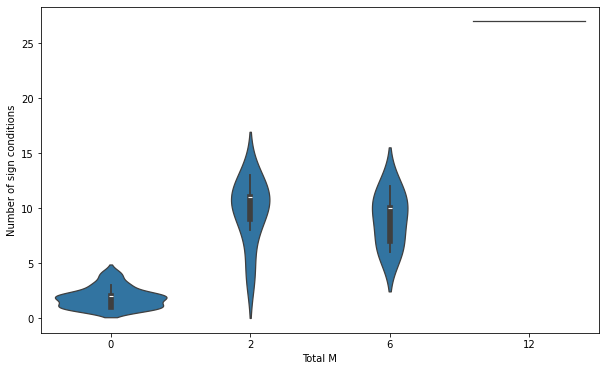

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

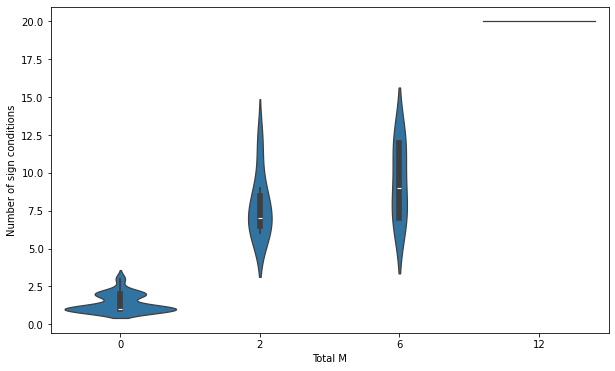

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

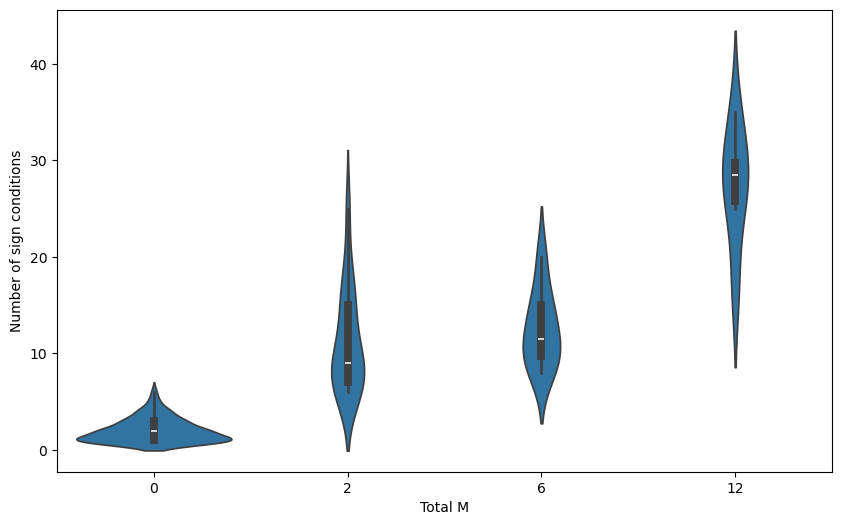

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

Text(0, 0.5, 'Number of sign conditions')

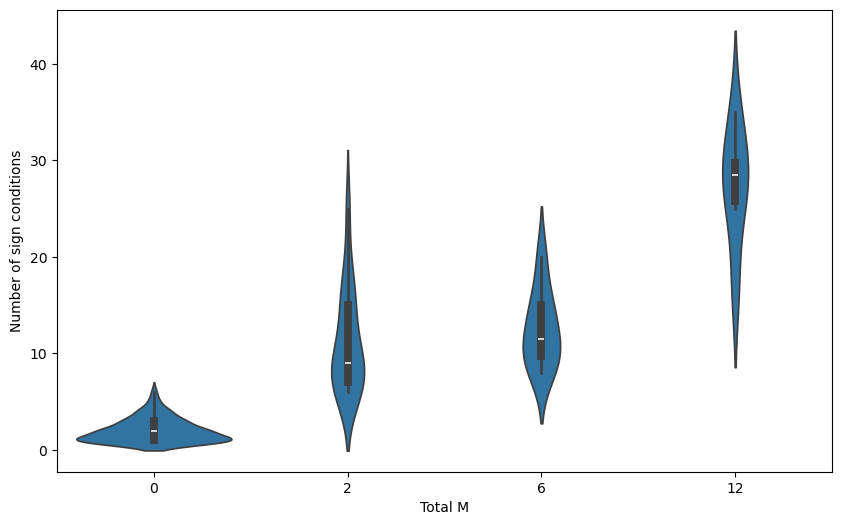

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)